# Hurricane Helene satellite dataset — analyst walkthrough

**Purpose.** Characterize the dataset shared by the collaborator (26 Hurricane Helene landslide
sites in southwest Virginia + 260 matched counterfactual sites; Sentinel-2 and Sentinel-1
before/after chips): document the study design and its data-quality caveats, explain every
feature, verify that our reading of the data reproduces the collaborator's `test/` computation
exactly, and assess measurement quality and cross-site comparability. This notebook is
**descriptive only** — the estimator comparison (equal-weight DiD vs estimated-weight synthetic
control, placebo inference) is in `02_did_vs_synthetic_control.ipynb`.

Companion theory document: `REAP/Docs/tutorial_satellite_causal_2026-08-12.md`.

Every section ends with a *Provenance* line naming which of the collaborator's pipeline
notebooks (`data/scripts/00–09`) — and which numbered section inside it — produced the
artifact being examined, so each of our checks can be traced back to her code.

| notebook section | proposal objective / module |
|---|---|
| 1–3 study design, map, covariate balance | Obj. 1 (data pipeline; treated & comparison areas) |
| 4–5 images & feature dictionary | Obj. 2 / Module 1 (factual indicators) |
| 6–7 per-site features & pipeline validation | Obj. 1–2 (our pipeline reproduces the collaborator's) |
| 8–11 measurement quality & comparability | Obj. 1 QC; readiness checks for Module 2 |
| 12 dataset summary & gaps | Obj. 5 + timeline |


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

ROOT = Path("/data/wang/junh/githubs/latent-synthetic-control")
DATA = ROOT / "REAP" / "data"
FINALS = DATA / "finals"
TEST = DATA / "test" / "treatment_0001"
OUT = ROOT / "REAP" / "notebooks"

# validated categorical palette (dataviz reference instance, slots 1-3)
C_CONTROL, C_TREAT, C_ACCENT = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 10,
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "figure.titlesize": 12,
})

S2_BANDS = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI"]
S1_BANDS = ["VV", "VH", "VV_minus_VH"]
BANDS = {"sentinel2": S2_BANDS, "sentinel1": S1_BANDS}
NLCD = {21: "Developed, open space", 22: "Developed, low intensity",
        41: "Deciduous forest", 42: "Evergreen forest", 43: "Mixed forest",
        71: "Grassland/herbaceous", 81: "Pasture/hay"}

def chip_path(site_id: str, sensor: str, period: str) -> Path:
    group = "treatment" if site_id.startswith("treatment") else "counterfactual"
    return FINALS / sensor / group / period / f"{site_id}_{period}_{sensor}.tif"

def read_chip(path: Path) -> np.ndarray:
    """(H, W, C) float32 with the GeoTIFF's -inf nodata (and any nan) masked to nan.

    The finals chips encode nodata as -Infinity (NOT nan) — naive np.nanmean
    without this masking silently returns -inf.
    """
    arr = tifffile.imread(path).astype(np.float32)
    arr[~np.isfinite(arr)] = np.nan
    return arr

def rgb(chip, stretch=(0.0, 0.14)):
    """S2 chip -> display RGB (bands B4,B3,B2 = indices 2,1,0), linear stretch."""
    img = np.stack([chip[..., 2], chip[..., 1], chip[..., 0]], axis=-1)
    img = (img - stretch[0]) / (stretch[1] - stretch[0])
    return np.clip(np.nan_to_num(img, nan=1.0), 0, 1)

a = read_chip(chip_path("treatment_0001", "sentinel2", "before"))
b = read_chip(chip_path("treatment_0001", "sentinel1", "before"))
print(f"S2 chip: {a.shape}, S1 chip: {b.shape}   (101x101 px @ 10 m = 1.01 km windows)")


S2 chip: (101, 101, 8), S1 chip: (101, 101, 3)   (101x101 px @ 10 m = 1.01 km windows)


## 1. Study design — who is compared with whom

Treatment sites come from the USGS preliminary Hurricane Helene landslide inventory
(Burgi et al. 2025); each is matched to 10 counterfactual sites with the same NLCD
land-cover class, similar elevation and slope, at least 5 km from any mapped landslide,
never reused across treatments. `site_matching_table.csv` is the canonical link and should
always be used instead of parsing file names (the image folders contain 26 stray un-ranked
files per sensor/period that belong to no documented site).

*Provenance: treatment sites = the USGS Helene landslide inventory downloaded in her
`03_download_usgs.ipynb`, filtered to Virginia and given IDs in `06_create_sites.ipynb`
§7–10; elevation/slope come from the 3DEP DEM of `04_download_dem.ipynb`, land cover from
the NLCD 2021 raster of `05_download_landcover.ipynb` (both sampled at sites in 06 §10/§14);
candidate controls are generated and matched in 06 §12–17; `site_matching_table.csv` is
written in 06 §23 and copied to `finals/` in 06 §27.*

In [2]:
match = pd.read_csv(FINALS / "site_matching_table.csv")
tsites = json.loads((FINALS / "treatment_sites.geojson").read_text())["features"]
csites = json.loads((FINALS / "counterfactual_sites.geojson").read_text())["features"]

def props_df(feats):
    rows = []
    for f in feats:
        p = dict(f["properties"])
        xy = np.asarray(f["geometry"]["coordinates"][0], dtype=float)
        p["lon"], p["lat"] = xy[:, 0].mean(), xy[:, 1].mean()
        rows.append(p)
    return pd.DataFrame(rows)

tdf, cdf = props_df(tsites), props_df(csites)
sites = pd.concat([tdf, cdf], ignore_index=True)

print(f"treatment sites:      {len(tdf)}")
print(f"counterfactual sites: {len(cdf)}")
print(f"matches in table:     {len(match)}  "
      f"({match['treatment_site_id'].nunique()} treatments x "
      f"{match.groupby('treatment_site_id').size().unique()} controls)")
print(f"match quality:        {match['match_quality'].value_counts().to_dict()}")

nlcd_tab = (tdf["nlcd_class"].value_counts().rename("treatment sites").to_frame()
            .join(cdf["nlcd_class"].value_counts().rename("control sites")))
nlcd_tab.index = [f"{k} — {NLCD.get(k, '?')}" for k in nlcd_tab.index]
print("\nNLCD land-cover distribution:")
print(nlcd_tab.to_string())


treatment sites:      26
counterfactual sites: 260
matches in table:     260  (26 treatments x [10] controls)
match quality:        {'strict': 260}

NLCD land-cover distribution:
                               treatment sites  control sites
41 — Deciduous forest                       17            170
81 — Pasture/hay                             2             20
43 — Mixed forest                            2             20
21 — Developed, open space                   2             20
22 — Developed, low intensity                1             10
71 — Grassland/herbaceous                    1             10
42 — Evergreen forest                        1             10


In [3]:
quality = match[["elevation_difference_m", "slope_difference_deg",
                 "distance_km", "matching_score"]].describe().loc[
                 ["mean", "50%", "min", "max"]].T
print("Treatment-to-control matching quality (260 matches):")
print(quality.round(3).to_string())

by_rank = match.groupby("control_rank")["matching_score"].agg(["mean", "max"]).round(3)
print("\nMatching score by control rank (lower = better match):")
print(by_rank.to_string())

# data-quality notes, each traced to its origin in the collaborator's
# pipeline notebooks (data/scripts/):
ids = sorted(int(s.split("_")[1]) for s in tdf["site_id"])
gaps = sorted(set(range(ids[0], ids[-1] + 1)) - set(ids))
print(f"""
NOTE  treatment IDs run {ids[0]:04d}-{ids[-1]:04d}, missing: {[f'{g:04d}' for g in gaps]}.
      Origin: 06_create_sites.ipynb -- IDs are assigned to all 27 USGS VA
      landslides BEFORE matching (sec. 8-10); sec. 16-17 then drop any
      treatment without exactly 10 matched controls. The notebook's own
      output says: "treatment_0026 obtained only 4 of 10 required controls."
      So the gap is that documented rule firing once, not an accident.

NOTE  minimum control distance = {match['distance_km'].min():.2f} km. The pipeline implements a
      5 km exclusion (06_create_sites.ipynb sec. 5/11: LANDSLIDE_EXCLUSION_METERS
      = 5_000, and sec. 30 verifies it); the "10 km" in the collaborator's
      email is a misstatement, not a pipeline bug.

NOTE  104 stray un-ranked TIFFs (e.g. counterfactual_0001_before_sentinel2.tif).
      Origin: 07/08 download notebooks name files "{{site_id}}_{{period}}_{{sensor}}.tif"
      from whatever sites file they are given, SKIP already-existing files, and
      never clean the output folders -- so files from an earlier run with
      pre-rank site IDs survive alongside the current export (17 of 26 are
      byte-duplicates of a ranked sibling; 9 are from different locations).
      They are absent from every inventory/validation CSV; select files via
      site_matching_table.csv, never by globbing.""")


Treatment-to-control matching quality (260 matches):
                          mean     50%    min      max
elevation_difference_m  15.526  10.362  0.016  129.150
slope_difference_deg     0.828   0.505  0.004    6.003
distance_km             13.403  11.777  5.038   51.145
matching_score           0.241   0.208  0.071    0.659

Matching score by control rank (lower = better match):
               mean    max
control_rank              
1             0.167  0.526
2             0.202  0.562
3             0.213  0.578
4             0.232  0.594
5             0.242  0.597
6             0.252  0.600
7             0.262  0.602
8             0.271  0.611
9             0.281  0.656
10            0.288  0.659

NOTE  treatment IDs run 0001-0027, missing: ['0026'].
      Origin: 06_create_sites.ipynb -- IDs are assigned to all 27 USGS VA
      landslides BEFORE matching (sec. 8-10); sec. 16-17 then drop any
      treatment without exactly 10 matched controls. The notebook's own
      output says: "

## 2. Where the sites are

Treatment sites cluster along the Blue Ridge escarpment in southwest Virginia (orographic
rainfall maximum during Helene); controls spread over the surrounding study area. Grey lines
show one example group (`pair_0001`): a treatment site and its 10 donors.

*Provenance: `treatment_sites.geojson` / `counterfactual_sites.geojson` are written by
`06_create_sites.ipynb` §19–21 (converted to WGS84, saved) and copied to `finals/` in §27;
her own site map is 06 §28.*

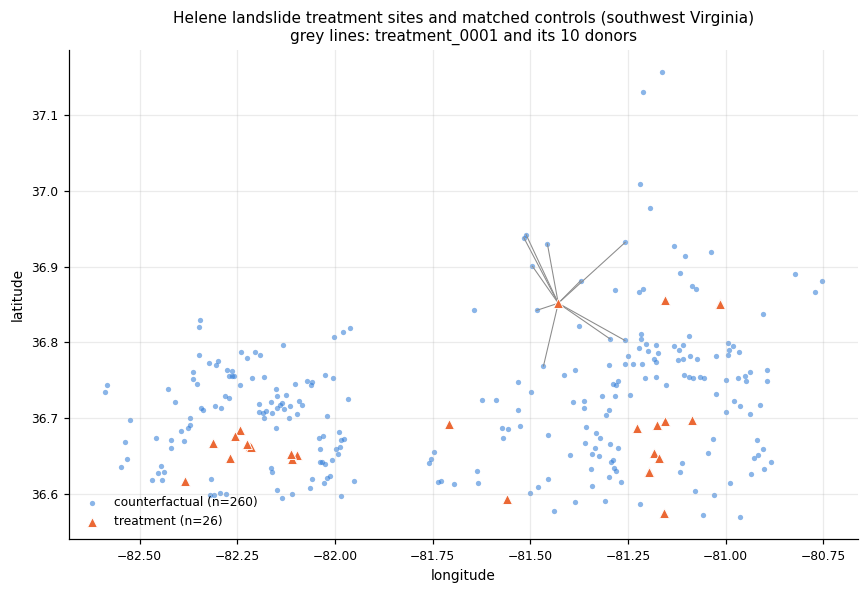

In [4]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(cdf["lon"], cdf["lat"], s=12, c=C_CONTROL, alpha=0.55, lw=0,
           label=f"counterfactual (n={len(cdf)})")
ax.scatter(tdf["lon"], tdf["lat"], s=42, c=C_TREAT, edgecolor="white", lw=0.6,
           marker="^", label=f"treatment (n={len(tdf)})", zorder=3)

g1 = match[match["pair_id"] == "pair_0001"]
t1 = tdf[tdf["site_id"] == "treatment_0001"].iloc[0]
for cid in g1["counterfactual_site_id"]:
    c1 = cdf[cdf["site_id"] == cid].iloc[0]
    ax.plot([t1["lon"], c1["lon"]], [t1["lat"], c1["lat"]],
            color="0.55", lw=0.7, zorder=1)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("Helene landslide treatment sites and matched controls (southwest Virginia)\n"
             "grey lines: treatment_0001 and its 10 donors")
ax.legend(loc="lower left", frameon=False)
plt.tight_layout(); plt.show()


## 3. Covariate balance — what matching bought, and what it left

Matching guarantees the *class* variable (NLCD) exactly; the remaining candidates are ranked
by the collaborator's **matching score** (`06_create_sites.ipynb` sec. 15), a covariate
distance between the treated site and a candidate control:

    score = |Δelevation| / 300 m  +  |Δslope| / 15°  +  distance / 100 km      (lower = better)

One *group* = one treated site plus its 10 ranked donors. Two spreads matter, both
quantified in the next cell: within a group the rank-10 donor's score is typically about
**twice** the rank-1 donor's (median 1.9×, up to 3.3×), and *between* groups the spread is
even larger — the best-matched group's mean score is 0.14, the worst's 0.59. The score is a
design-time quantity — it uses only pre-treatment covariates, never the satellite outcomes,
so ranking by it cannot bake the outcome into the design. Whether it *predicts* similarity
in the spectral feature space is a separate question, checked in section 10.

*Provenance:
selection of the 10 lowest-score candidates per treatment is 06 §16, the exactly-10 rule is
§17, and her own matching-quality checks are §25/§29. The covariates entering the score
come from `04_download_dem.ipynb` (elevation, slope) and `05_download_landcover.ipynb`
(NLCD), sampled in 06 §10/§14.*

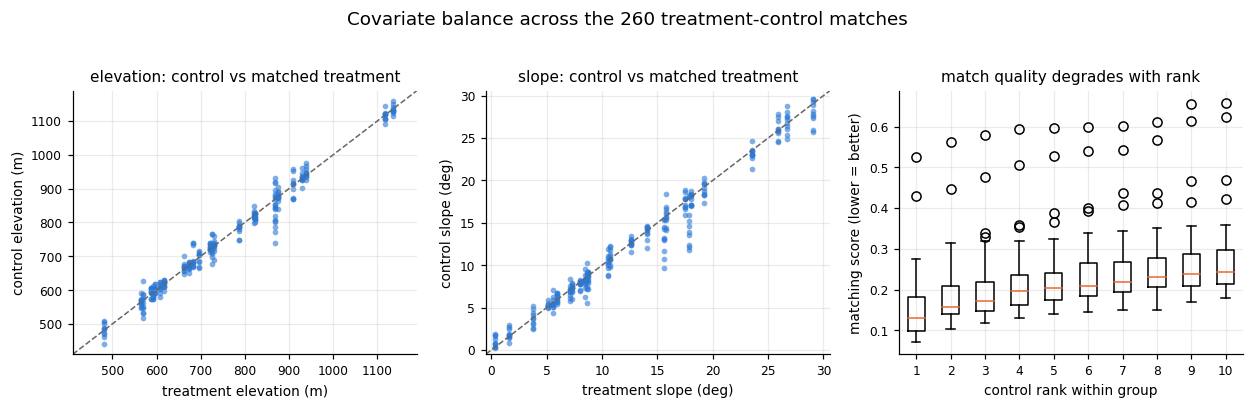

In [5]:
m = match.merge(tdf[["site_id", "elevation_m", "slope_deg"]],
                left_on="treatment_site_id", right_on="site_id", suffixes=("", "_t"))
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))

ax = axes[0]
ax.scatter(m["treatment_elevation_m"], m["counterfactual_elevation_m"],
           s=14, c=C_CONTROL, alpha=0.6, lw=0)
lims = [m[["treatment_elevation_m", "counterfactual_elevation_m"]].min().min() - 30,
        m[["treatment_elevation_m", "counterfactual_elevation_m"]].max().max() + 30]
ax.plot(lims, lims, color="0.4", lw=1, ls="--"); ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("treatment elevation (m)"); ax.set_ylabel("control elevation (m)")
ax.set_title("elevation: control vs matched treatment")

ax = axes[1]
ax.scatter(m["treatment_slope_deg"], m["counterfactual_slope_deg"],
           s=14, c=C_CONTROL, alpha=0.6, lw=0)
lims = [-0.5, max(m["treatment_slope_deg"].max(), m["counterfactual_slope_deg"].max()) + 1]
ax.plot(lims, lims, color="0.4", lw=1, ls="--"); ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("treatment slope (deg)"); ax.set_ylabel("control slope (deg)")
ax.set_title("slope: control vs matched treatment")

ax = axes[2]
ranks = sorted(match["control_rank"].unique())
ax.boxplot([match.loc[match["control_rank"] == r, "matching_score"] for r in ranks],
           labels=ranks, medianprops=dict(color=C_TREAT))
ax.set_xlabel("control rank within group"); ax.set_ylabel("matching score (lower = better)")
ax.set_title("match quality degrades with rank")
fig.suptitle("Covariate balance across the 260 treatment-control matches", y=1.02)
plt.tight_layout(); plt.show()


rank-10 score / rank-1 score within a group: median 1.9x, range 1.2x - 3.3x
between groups: mean score ranges 0.14 (best) to 0.59 (worst) -- a 4.3x spread, larger than the within-group one

BEST-matched group: treatment_0005  (mean score 0.14)
 control_rank counterfactual_site_id  elevation_difference_m  slope_difference_deg  distance_km  matching_score
            1 counterfactual_0005_01                    3.35                  0.12         5.15            0.07
            2 counterfactual_0005_02                   13.72                  0.08         5.13            0.10
            9 counterfactual_0005_09                   17.76                  0.34         8.83            0.17
           10 counterfactual_0005_10                   18.67                  0.01        12.39            0.19

WORST-matched group: treatment_0016  (mean score 0.59)
 control_rank counterfactual_site_id  elevation_difference_m  slope_difference_deg  distance_km  matching_score
            1 counterfactual

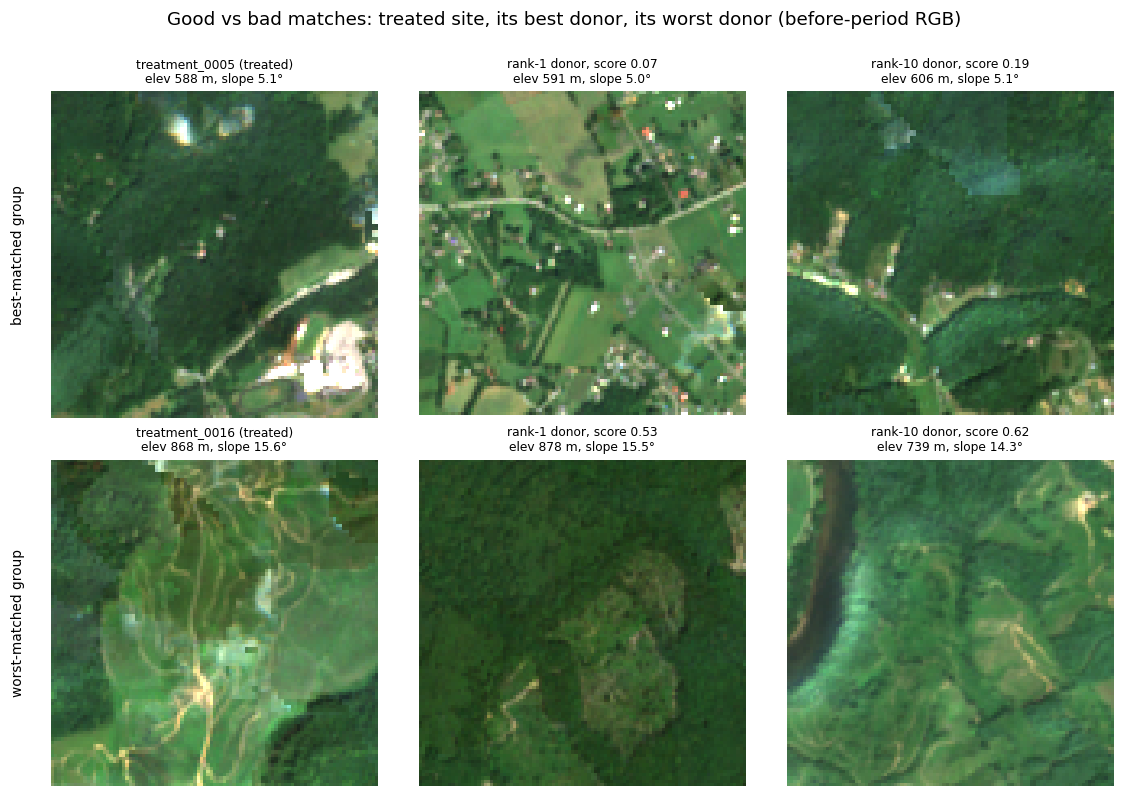

In [6]:
# make the rank-1 -> rank-10 degradation concrete: the best-matched and the
# worst-matched group in the dataset, each with its best and worst donors
g = match.groupby("treatment_site_id")["matching_score"]
ratio = g.max() / g.min()
print(f"rank-10 score / rank-1 score within a group: median {ratio.median():.1f}x, "
      f"range {ratio.min():.1f}x - {ratio.max():.1f}x")
gm = g.mean()
print(f"between groups: mean score ranges {gm.min():.2f} (best) to {gm.max():.2f} (worst) "
      f"-- a {gm.max()/gm.min():.1f}x spread, larger than the within-group one")

best_t, worst_t = g.mean().idxmin(), g.mean().idxmax()
cols = ["control_rank", "counterfactual_site_id", "elevation_difference_m",
        "slope_difference_deg", "distance_km", "matching_score"]
for label, t in [("BEST-matched group", best_t), ("WORST-matched group", worst_t)]:
    grp = match[match["treatment_site_id"] == t].sort_values("control_rank")
    show = grp.loc[grp["control_rank"].isin([1, 2, 9, 10]), cols]
    print(f"\n{label}: {t}  (mean score {grp['matching_score'].mean():.2f})")
    print(show.round(2).to_string(index=False))

site_props = sites.set_index("site_id")
fig, axes = plt.subplots(2, 3, figsize=(10.5, 7.2))
for row, (label, t) in enumerate([("best-matched group", best_t),
                                  ("worst-matched group", worst_t)]):
    grp = match[match["treatment_site_id"] == t].sort_values("control_rank")
    trio = [(t, f"{t} (treated)"),
            (grp.iloc[0]["counterfactual_site_id"],
             f"rank-1 donor, score {grp.iloc[0]['matching_score']:.2f}"),
            (grp.iloc[-1]["counterfactual_site_id"],
             f"rank-10 donor, score {grp.iloc[-1]['matching_score']:.2f}")]
    for col, (sid, lab) in enumerate(trio):
        chip = read_chip(chip_path(sid, "sentinel2", "before"))
        ax = axes[row, col]
        ax.imshow(rgb(chip)); ax.axis("off"); ax.grid(False)
        p = site_props.loc[sid]
        ax.set_title(f"{lab}\nelev {p['elevation_m']:.0f} m, slope {p['slope_deg']:.1f}°",
                     fontsize=8)
    axes[row, 0].text(-0.08, 0.5, label, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=9)
fig.suptitle("Good vs bad matches: treated site, its best donor, its worst donor "
             "(before-period RGB)", y=1.0)
plt.tight_layout(); plt.show()


## 4. What the images look like

Top rows: the treatment site and its best-matched control, before and after the hurricane
(S2 true color and NDVI; S1 VV backscatter). Bottom row: the pixel-wise mean across all 10
controls, as computed in the collaborator's `test/treatment_0001/` folder — averaging ten
different real places pixel-by-pixel yields a smooth composite with no recognizable terrain
features (individual ridges and fields cancel out).

*Provenance: each chip is a Google-Earth-Engine **median** composite over the period.
S2 chips: `07_download_sentinel2.ipynb` — SCL cloud/shadow mask §11, median composite with
NDVI/NDWI §13, per-site download §16/§18. S1 chips: `08_download_sentinel1.ipynb` — orbit
availability diagnostics §13–14 (ASCENDING selected), edge-pixel mask §16, composite with
VV−VH §17, download §20/§22. The 1 km × 1 km site windows are drawn in
`06_create_sites.ipynb` §18. The mean-of-10-controls composites are
`09_test_counterfactual_average.ipynb` (the `test/treatment_0001/` folder). The validation
CSVs read below are 07 §23 and 08 §27.*

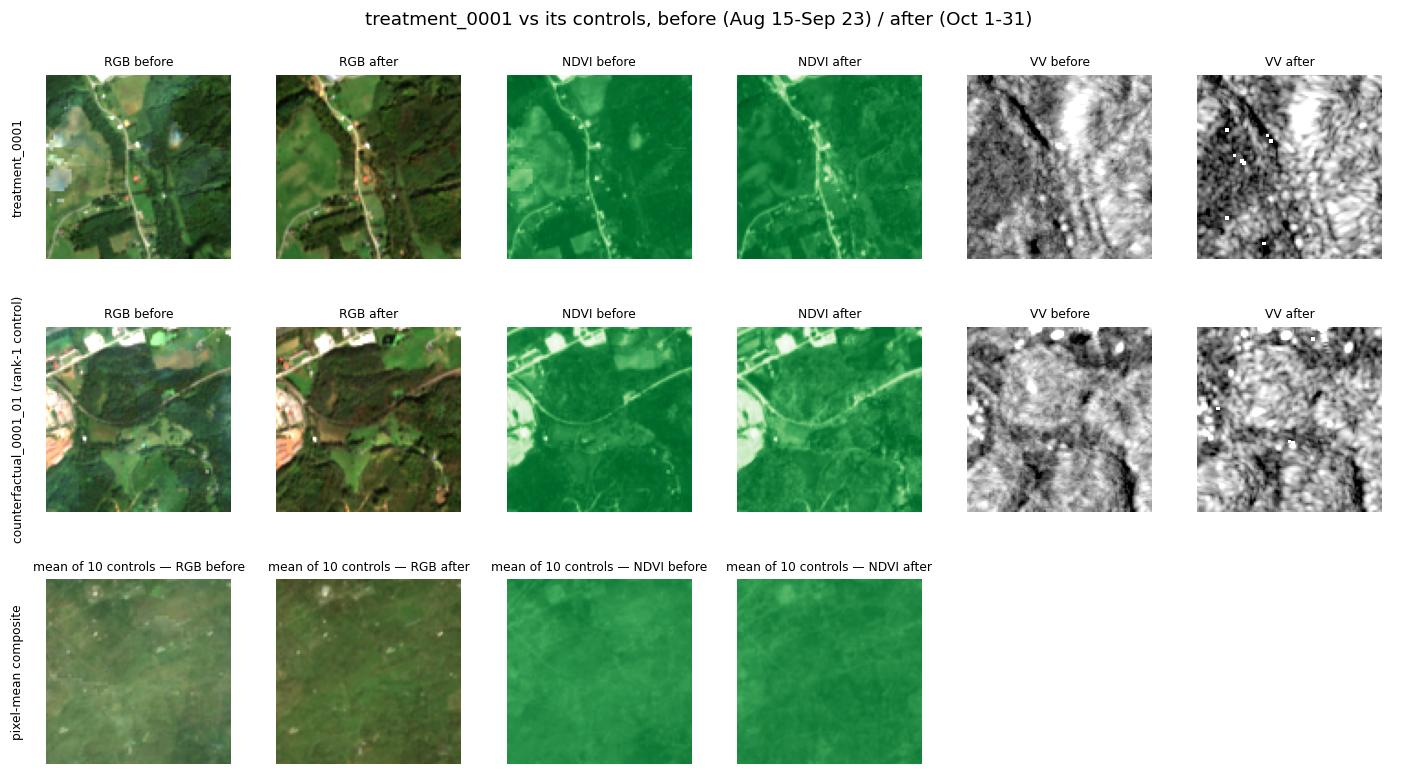

In [7]:
t_id, c_id = "treatment_0001", match.loc[match["pair_id"] == "pair_0001"].iloc[0]["counterfactual_site_id"]
panels = []
for sid, label in [(t_id, "treatment_0001"), (c_id, f"{c_id} (rank-1 control)")]:
    s2b, s2a = (read_chip(chip_path(sid, "sentinel2", p)) for p in ("before", "after"))
    s1b, s1a = (read_chip(chip_path(sid, "sentinel1", p)) for p in ("before", "after"))
    panels.append((label, s2b, s2a, s1b, s1a))
mean_b = tifffile.imread(TEST / "sentinel2" / "mean_control_before.tif").astype(np.float32)
mean_a = tifffile.imread(TEST / "sentinel2" / "mean_control_after.tif").astype(np.float32)

fig, axes = plt.subplots(3, 6, figsize=(13, 7))
for row, (label, s2b, s2a, s1b, s1a) in enumerate(panels):
    ims = [rgb(s2b), rgb(s2a), s2b[..., 6], s2a[..., 6], s1b[..., 0], s1a[..., 0]]
    kinds = ["RGB before", "RGB after", "NDVI before", "NDVI after", "VV before", "VV after"]
    for col, (im, kind) in enumerate(zip(ims, kinds)):
        ax = axes[row, col]
        if "NDVI" in kind:
            h = ax.imshow(im, cmap="Greens", vmin=0, vmax=1)
        elif "VV" in kind:
            h = ax.imshow(im, cmap="gray", vmin=-18, vmax=-4)
        else:
            ax.imshow(im)
        ax.set_title(f"{kind}", fontsize=8); ax.axis("off")
    axes[row, 0].set_ylabel(label)
    axes[row, 0].text(-0.12, 0.5, label, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=8)
for col, (im, kind) in enumerate(zip(
        [rgb(mean_b), rgb(mean_a), mean_b[..., 6], mean_a[..., 6]],
        ["RGB before", "RGB after", "NDVI before", "NDVI after"])):
    ax = axes[2, col]
    if "NDVI" in kind:
        ax.imshow(im, cmap="Greens", vmin=0, vmax=1)
    else:
        ax.imshow(im)
    ax.set_title(f"mean of 10 controls — {kind}", fontsize=8); ax.axis("off")
for col in (4, 5):
    axes[2, col].axis("off")
axes[2, 0].text(-0.12, 0.5, "pixel-mean composite", transform=axes[2, 0].transAxes,
                rotation=90, va="center", ha="right", fontsize=8)
fig.suptitle("treatment_0001 vs its controls, before (Aug 15-Sep 23) / after (Oct 1-31)", y=1.0)
plt.tight_layout(); plt.show()


In [8]:
# image quality: every documented chip validates; worst valid-pixel fraction 97.5%
frames = []
for sensor in ("sentinel2", "sentinel1"):
    v = pd.read_csv(FINALS / sensor / f"{sensor}_image_validation.csv")
    frames.append(pd.DataFrame({
        "sensor": sensor, "images": len(v),
        "readable": v["readable"].sum(),
        "min valid px frac": round(float(v["valid_pixel_fraction"].min()), 4),
        "median valid px frac": float(v["valid_pixel_fraction"].median()),
    }, index=[0]))
print(pd.concat(frames, ignore_index=True).to_string(index=False))


   sensor  images  readable  min valid px frac  median valid px frac
sentinel2     572       572             0.9901                   1.0
sentinel1     572       572             0.9748                   1.0


## 5. Feature dictionary — what each band measures and how we will use it

The "signature" column gives the **a-priori physical expectation** for a landslide scar;
whether the data bear these signs out is an estimation question, answered in notebook 02.

| band | sensor | physical meaning | a-priori landslide signature | role in the proposal |
|---|---|---|---|---|
| B2 (Blue) | S2 optical | blue reflectance; haze, water | slight ↑ (exposed soil brighter than canopy) | Module 1 indicator input; RGB visualization |
| B3 (Green) | S2 | green reflectance; vegetation vigor | slight ↑ | Module 1; RGB |
| B4 (Red) | S2 | red reflectance; chlorophyll absorption | ↑ (vegetation loss removes absorption) | Module 1; RGB; NDVI input |
| B8 (NIR) | S2 | near-infrared; healthy canopy reflects strongly | ↓ (canopy destroyed) | Module 1; NDVI/NDWI input |
| B11 (SWIR1) | S2 | shortwave IR; moisture + bare soil | ↑ (exposed mineral soil) | Module 1; NBR-like burn/disturbance signal |
| B12 (SWIR2) | S2 | shortwave IR; drier/mineral surfaces | ↑ | Module 1 |
| NDVI | S2 derived | (NIR−Red)/(NIR+Red), vegetation health | ↓ — the headline optical signal | Module 1 primary indicator; Module 3 translation to "vegetation stress" |
| NDWI | S2 derived | (Green−NIR)/(Green+NIR), surface water/wetness | ↑ toward 0 (vegetation loss); ↑↑ if ponded water | Module 1 water/flood indicator |
| VV | S1 radar | co-pol backscatter (dB); surface roughness, soil moisture | ± (roughness change; direction is land-cover dependent — Mondini 2019) | Module 1 all-weather indicator; independent of the optical inventory (circularity guard, tutorial §6) |
| VH | S1 radar | cross-pol backscatter (dB); volume scattering from canopy/debris structure | ± — canopy loss lowers it, rough debris raises it | Module 1; vegetation-structure change |
| VV−VH | S1 derived | polarization ratio; separates surface vs volume scattering | ± — sharper separation of structure change than either channel alone | Module 1 |

Two measurement facts to keep in mind: **(1)** the "after" S1 composites stack a median of
only 1 scene vs 3 before (quantified per site in section 8; known for control sites only —
treatment metadata is missing), so radar speckle is noisier after the storm; **(2)** the
USGS inventory itself was built largely from S2 NDVI change, so NDVI change partly restates
treatment assignment — S1 is the independent modality (tutorial §6).

*Provenance: the before/after date windows are set identically in `07`/`08` §5
(2024-08-15→09-23 and 10-01→31). The S2 band list (with NDVI/NDWI computed via
`normalizedDifference`, scenes above 80% cloud dropped) is 07 §6/§13; the S1 band list
(IW GRD VV/VH, VV−VH derived) is 08 §6/§17.*

## 6. Per-site band features for all 286 sites

Site-level masked means per band, sensor, and period — the transparent feature space the
proposal's Module 2 baseline operates in. The `change` rows are means of the **pixelwise**
after−before image (computed over the intersection of the two valid masks), which is the
collaborator's convention in `test/` — with S1's few masked low-backscatter pixels,
differencing the two period means instead shifts values by up to ~0.005 dB. Computed once
and cached to `site_band_features.csv`.

*Provenance: the extraction below is ours; the chips it reads are 07/08 outputs, and the
pixelwise-change convention it follows is `09_test_counterfactual_average.ipynb`.*

In [9]:
feat_csv = OUT / "site_band_features.csv"
if feat_csv.exists():
    feats = pd.read_csv(feat_csv)
else:
    rows = []
    for sid in sites["site_id"]:
        for sensor in ("sentinel2", "sentinel1"):
            b = read_chip(chip_path(sid, sensor, "before"))
            a = read_chip(chip_path(sid, sensor, "after"))
            for period, chip in (("before", b), ("after", a), ("change", a - b)):
                row = {"site_id": sid, "sensor": sensor, "period": period,
                       "valid_frac": float(np.isfinite(chip[..., 0]).mean())}
                for bi, band in enumerate(BANDS[sensor]):
                    row[band] = float(np.nanmean(chip[..., bi]))
                rows.append(row)
    feats = pd.DataFrame(rows)
    feats.to_csv(feat_csv, index=False)

ALL_BANDS = S2_BANDS + S1_BANDS
wide = (feats.melt(id_vars=["site_id", "sensor", "period"],
                   value_vars=None, var_name="band")
        .query("band in @ALL_BANDS")
        .pivot_table(index="site_id", columns=["period", "band"], values="value"))
before = wide["before"][ALL_BANDS]
change = wide["change"][ALL_BANDS]
print(f"feature table: {len(feats)} rows ({feats['site_id'].nunique()} sites x 2 sensors x 3 rows)")
print("\nbefore-period feature means (population):")
print(before.describe().loc[["mean", "std"]].T.round(4).to_string())


feature table: 1716 rows (286 sites x 2 sensors x 3 rows)

before-period feature means (population):
                mean     std
band                        
B2            0.0352  0.0069
B3            0.0554  0.0083
B4            0.0355  0.0096
B8            0.3493  0.0275
B11           0.1942  0.0253
B12           0.0892  0.0191
NDVI          0.8127  0.0513
NDWI         -0.7227  0.0440
VV           -9.8783  0.9542
VH          -16.1485  0.8794
VV_minus_VH   6.2702  0.2390


## 7. Pipeline validation — we reproduce the collaborator's `test/` exactly

The `test/` folder computes, for `treatment_0001`:

    adjusted effect = (treatment change) − (mean change across its 10 controls)

pixel-wise, then averages. Before using any feature we derived, we verify that our chip
reading (nodata masking, band order, mask-intersection convention) reproduces her published
numbers to float precision.

*Provenance: the reference numbers (`counterfactual_feature_summary.csv` and the
mean/median control composites) are written by `09_test_counterfactual_average.ipynb` into
`test/treatment_0001/`.*

In [10]:
# exact pixel-level replication of the collaborator's test for treatment_0001:
# mean_adjusted_effect = pixel mean of [ (T_after - T_before) - (C̄_after - C̄_before) ]
# where C̄ is the pixelwise nanmean over the 10 control chips
ctrl_ids = match.loc[match["treatment_site_id"] == "treatment_0001"] \
    .sort_values("control_rank")["counterfactual_site_id"].tolist()
ours = {}
for sensor in ("sentinel2", "sentinel1"):
    tb, ta = (read_chip(chip_path("treatment_0001", sensor, p)) for p in ("before", "after"))
    cb = np.nanmean(np.stack([read_chip(chip_path(c, sensor, "before")) for c in ctrl_ids]), axis=0)
    ca = np.nanmean(np.stack([read_chip(chip_path(c, sensor, "after")) for c in ctrl_ids]), axis=0)
    adj = (ta - tb) - (ca - cb)
    for bi, band in enumerate(BANDS[sensor]):
        ours[band] = float(np.nanmean(adj[..., bi]))

site_level = change.loc["treatment_0001"] - change.loc[ctrl_ids].mean()

ref = pd.read_csv(TEST / "counterfactual_feature_summary.csv")
comp = ref[["band", "mean_adjusted_effect"]].assign(
    ours=lambda d: d["band"].map(ours).astype(float))
comp["abs diff"] = (comp["mean_adjusted_effect"] - comp["ours"]).abs()
comp["site-level analog"] = comp["band"].map(site_level).astype(float)
print("validation vs collaborator's counterfactual_feature_summary.csv (treatment_0001):")
print(comp.round(6).to_string(index=False))
assert comp["abs diff"].max() < 1e-4, "pipeline disagrees with the collaborator's test"
print(f"\nmax |difference| = {comp['abs diff'].max():.2e}  -> our pipeline reproduces theirs")
print("(the site-level analog column applies the same formula to the cached site features;")
print(" it differs only where control chips have masked pixels)")


validation vs collaborator's counterfactual_feature_summary.csv (treatment_0001):
       band  mean_adjusted_effect      ours  abs diff  site-level analog
         B2              0.003889  0.003889       0.0           0.003892
         B3              0.002788  0.002788       0.0           0.002792
         B4              0.005746  0.005746       0.0           0.005756
         B8             -0.013545 -0.013545       0.0          -0.013570
        B11              0.016069  0.016069       0.0           0.016088
        B12              0.012793  0.012793       0.0           0.012811
       NDVI             -0.027130 -0.027130       0.0          -0.027185
       NDWI              0.015135  0.015135       0.0           0.015161
         VV             -0.212466 -0.212466       0.0          -0.211456
         VH              0.142442  0.142442       0.0           0.144335
VV_minus_VH             -0.354908 -0.354908       0.0          -0.355791

max |difference| = 3.81e-10  -> our pipel

## 8. Composite depth and acquisition geometry — how much signal is behind each chip

Each chip is a temporal composite; the number of stacked scenes bounds its noise level.
The inventories record `scene_count` per site and period, and for S1 also the relative
orbit(s) — but, it turns out, **only for the 260 control sites**. Every treatment row in
both sensors' inventories has NaN acquisition metadata. The origin is the same skip-existing
behavior that produced the stray TIFFs: in `07/08_download_*.ipynb` each download record is
initialized with `scene_count = np.nan`, and when the output file already exists (the
treatment chips predate the final run; `OVERWRITE_EXISTING = False`) the function returns
with status `"existing"` without ever querying GEE for the metadata. Worth asking the
collaborator to re-export the treatment metadata; the images themselves are fine.

So the questions become: **(a)** how thin are the after-period composites (controls, the
only sites with metadata)? **(b)** are the 10 donors within each group imaged from the same
S1 orbit configuration? (SAR backscatter is incidence-angle dependent — donors on different
relative orbits carry a systematic offset that has nothing to do with landslides. The
treatment's own orbit is unknowable from the metadata.)

We also compute the per-site valid-mask **intersection** fraction (before ∩ after) — the
pixels that actually enter the pixelwise-change convention — cached with the pixel-level
statistics used in section 11.

*Provenance: `scene_count` is recorded inside the download functions of 07 §16/§18 and
08 §20/§22 (which is exactly why the skip path leaves it NaN); the analysis-ready
inventories are 07 §24 and 08 §28; the region-wide orbit diagnostics CSV is written by
08 §13; the mask fractions below are ours, from the chips.*

In [11]:
inv = {}
for sensor in ("sentinel2", "sentinel1"):
    df = pd.read_csv(FINALS / sensor / f"{sensor}_analysis_ready_inventory.csv")
    inv[sensor] = df
    n_nan = df.groupby("group")["scene_count"].apply(lambda s: int(s.isna().sum()))
    print(f"{sensor}: chips with missing scene_count by group: {n_nan.to_dict()}")
    tab = df[df["group"] == "counterfactual"].pivot_table(
        index="period", values="scene_count",
        aggfunc=["min", "median", "max", "mean"]).round(2)
    tab.columns = [c[0] for c in tab.columns]
    print(f"{sensor}: scenes per composite (260 control sites — treatment metadata is NaN)")
    print(tab.loc[["before", "after"]].to_string(), "\n")

s1 = inv["sentinel1"]
s1c = s1[s1["group"] == "counterfactual"]
print("S1 after-period scene-count distribution (controls):")
print(s1c.loc[s1c["period"] == "after", "scene_count"].value_counts().sort_index().to_string())
print("\nS1 orbit passes used:", sorted(s1c["orbit_pass"].dropna().unique()))
print("region-wide S1 scenes (metadata/sentinel1_orbit_diagnostics.csv):")
print(pd.read_csv(DATA / "metadata" / "sentinel1_orbit_diagnostics.csv").to_string(index=False))

# orbit homogeneity among the 10 donors of each group (before period)
b1 = s1c[s1c["period"] == "before"].set_index("site_id")["relative_orbits"].astype(str)
rows = []
for t_id_, grp in match.groupby("treatment_site_id"):
    ctrl_ids_ = grp.sort_values("control_rank")["counterfactual_site_id"].tolist()
    combos = b1.loc[ctrl_ids_].value_counts()
    rows.append({"treatment": t_id_, "distinct donor orbit sets": len(combos),
                 "largest share": int(combos.iloc[0])})
orb = pd.DataFrame(rows).set_index("treatment")
n_homog = int((orb["distinct donor orbit sets"] == 1).sum())
print(f"\ngroups whose 10 donors all share one relative-orbit set: {n_homog}/26")
print("donor orbit sets across the 260 controls:", b1.value_counts().to_dict())


sentinel2: chips with missing scene_count by group: {'counterfactual': 0, 'treatment': 52}
sentinel2: scenes per composite (260 control sites — treatment metadata is NaN)
        min  median   max  mean
period                         
before  6.0     6.0  27.0  9.04
after   5.0     6.0  20.0  7.60 

sentinel1: chips with missing scene_count by group: {'counterfactual': 0, 'treatment': 52}
sentinel1: scenes per composite (260 control sites — treatment metadata is NaN)
        min  median  max  mean
period                        
before  3.0     3.0  7.0  4.69
after   1.0     1.0  4.0  2.32 

S1 after-period scene-count distribution (controls):
1.0    142
3.0     10
4.0    108

S1 orbit passes used: ['ASCENDING']
region-wide S1 scenes (metadata/sentinel1_orbit_diagnostics.csv):
orbit_pass period start_date   end_date  scene_count
 ASCENDING before 2024-08-15 2024-09-23            7
 ASCENDING  after 2024-10-01 2024-10-31            4
DESCENDING before 2024-08-15 2024-09-23            0
D

In [12]:
# per-site pixel-level statistics (one pass over all 572 chips, cached).
# Columns: valid-mask fractions (before, after, intersection) and pixelwise-change
# quantiles + extreme-pixel fractions for the sensor's key band
# (NDVI for S2, VV for S1). Used here (masks) and in section 11 (heterogeneity).
KEY = {"sentinel2": ("NDVI", 6), "sentinel1": ("VV", 0)}
EXT = {"sentinel2": (-0.10, -0.20),   # NDVI change thresholds
       "sentinel1": (-2.0, -4.0)}     # VV change thresholds (dB)
pix_csv = OUT / "site_pixel_stats.csv"
if pix_csv.exists():
    pix = pd.read_csv(pix_csv)
else:
    rows = []
    for sid in sites["site_id"]:
        for sensor in ("sentinel2", "sentinel1"):
            bchip = read_chip(chip_path(sid, sensor, "before"))
            achip = read_chip(chip_path(sid, sensor, "after"))
            band, bi = KEY[sensor]
            vb = np.isfinite(bchip[..., bi]); va = np.isfinite(achip[..., bi])
            both = vb & va
            d = (achip[..., bi] - bchip[..., bi])[both]
            t1, t2 = EXT[sensor]
            q = np.percentile(d, [1, 5, 50, 95, 99])
            rows.append({
                "site_id": sid, "sensor": sensor, "band": band,
                "valid_before": float(vb.mean()), "valid_after": float(va.mean()),
                "valid_both": float(both.mean()),
                "chg_p01": float(q[0]), "chg_p05": float(q[1]), "chg_p50": float(q[2]),
                "chg_p95": float(q[3]), "chg_p99": float(q[4]),
                "frac_below_t1": float((d < t1).mean()),
                "frac_below_t2": float((d < t2).mean()),
            })
    pix = pd.DataFrame(rows)
    pix.to_csv(pix_csv, index=False)

msk = pix.pivot_table(index="sensor",
                      values=["valid_before", "valid_after", "valid_both"],
                      aggfunc=["min", "median"]).round(4)
print("valid-pixel fractions across the 286 sites (per sensor):")
print(msk.to_string())
print("\nReading: masks are near-complete; the change convention loses at most "
      f"{100 * (1 - pix['valid_both'].min()):.1f}% of pixels at the worst site. "
      "The binding measurement constraints are composite depth and metadata, not "
      "masking: after-period S1 control chips stack a median of 1 scene (vs 3 "
      "before), so post-storm radar features carry unaveraged speckle; treatment "
      "composite depth is simply unknown (NaN metadata); and 5 of 26 donor groups "
      "mix different S1 relative orbits. A multi-date re-export would fix all three.")


valid-pixel fractions across the 286 sites (per sensor):
                  min                              median                        
          valid_after valid_before valid_both valid_after valid_before valid_both
sensor                                                                           
sentinel1      0.9748       0.9901     0.9743         1.0          1.0        1.0
sentinel2      0.9901       0.9901     0.9901         1.0          1.0        1.0

Reading: masks are near-complete; the change convention loses at most 2.6% of pixels at the worst site. The binding measurement constraints are composite depth and metadata, not masking: after-period S1 control chips stack a median of 1 scene (vs 3 before), so post-storm radar features carry unaveraged speckle; treatment composite depth is simply unknown (NaN metadata); and 5 of 26 donor groups mix different S1 relative orbits. A multi-date re-export would fix all three.


## 9. The common shock — what happened to the *control* sites

Before = Aug 15–Sep 23; after = Oct 1–31. Even far from any landslide, the after−before
change is large and systematic: autumn senescence (leaf-off begins in October in the Blue
Ridge) plus any region-wide storm effects (soil moisture, scattered wind damage). The control
distribution is the empirical picture of that common shock — a dataset fact with two design
consequences: **(a)** raw before/after differences at treatment sites are dominated by
season, so any causal contrast must difference against controls; **(b)** with a single
pre-period there is no way to check how parallel the seasonal trajectories actually are —
the case for re-exporting a monthly 2023–24 panel.

*Provenance: the two date windows are her choice in 07/08 §5; the control sites are 06
§12–17. The change distributions below are ours, from the cached features of section 6.*

After − before change at the 260 control sites (no landslide):
             control mean change  SD across 260 controls   t vs 0
band                                                             
B2                       -0.0151                  0.0041 -59.8279
B3                       -0.0121                  0.0036 -54.1086
B4                        0.0001                  0.0057   0.4140
B8                       -0.0732                  0.0303 -38.9206
B11                      -0.0074                  0.0105 -11.3759
B12                       0.0034                  0.0091   6.1318
NDVI                     -0.0465                  0.0435 -17.2268
NDWI                     -0.0028                  0.0257  -1.7354
VV                       -0.1142                  0.2040  -9.0283
VH                        0.2147                  0.3181  10.8806
VV_minus_VH              -0.3289                  0.2480 -21.3851


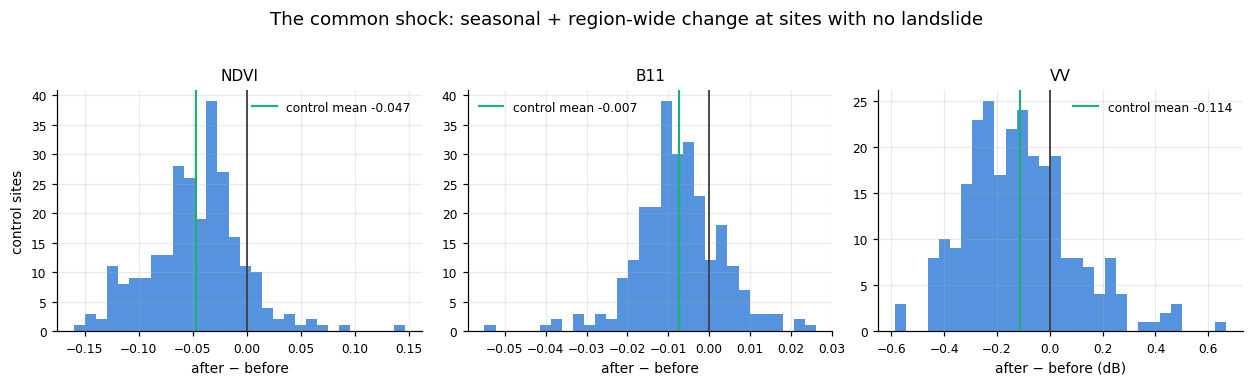

In [13]:
ctrl_chg = change.loc[cdf["site_id"]]
common = pd.DataFrame({
    "control mean change": ctrl_chg.mean(),
    "SD across 260 controls": ctrl_chg.std(),
    "t vs 0": ctrl_chg.mean() / (ctrl_chg.std() / np.sqrt(len(ctrl_chg))),
}).loc[ALL_BANDS]
print("After − before change at the 260 control sites (no landslide):")
print(common.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))
for ax, band in zip(axes, ["NDVI", "B11", "VV"]):
    ax.hist(ctrl_chg[band], bins=30, color=C_CONTROL, alpha=0.8)
    ax.axvline(0, color="0.25", lw=1.2)
    ax.axvline(ctrl_chg[band].mean(), color=C_ACCENT, lw=1.4,
               label=f"control mean {ctrl_chg[band].mean():+.3f}")
    unit = " (dB)" if band in S1_BANDS else ""
    ax.set_xlabel(f"after − before{unit}"); ax.set_title(band)
    ax.legend(frameon=False)
axes[0].set_ylabel("control sites")
fig.suptitle("The common shock: seasonal + region-wide change at sites with no landslide", y=1.02)
plt.tight_layout(); plt.show()


## 10. Feature-space comparability — is the matched design workable in band space?

The matching used NLCD class, elevation, and slope — never the spectral features themselves.
Four checks on what that bought in the 11-band space where any feature-space method will
operate: **(a)** how redundant the 11 bands are (correlation / effective dimensionality);
**(b)** whether treatments and the control pool are spectrally balanced (standardized mean
differences); **(c)** whether the covariate match rank predicts spectral similarity;
**(d)** whether each treatment lies inside its donors' per-band range (interpolation) or
outside it (extrapolation).

*Provenance: the matched design being tested is `06_create_sites.ipynb` §15–17; the band
features are ours (section 6) from her 07/08 chips. All four checks are ours — she does not
examine spectral balance anywhere in 00–09.*

/tmp/ipykernel_4142573/3535127800.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(im, ax=axes[0], shrink=0.85)


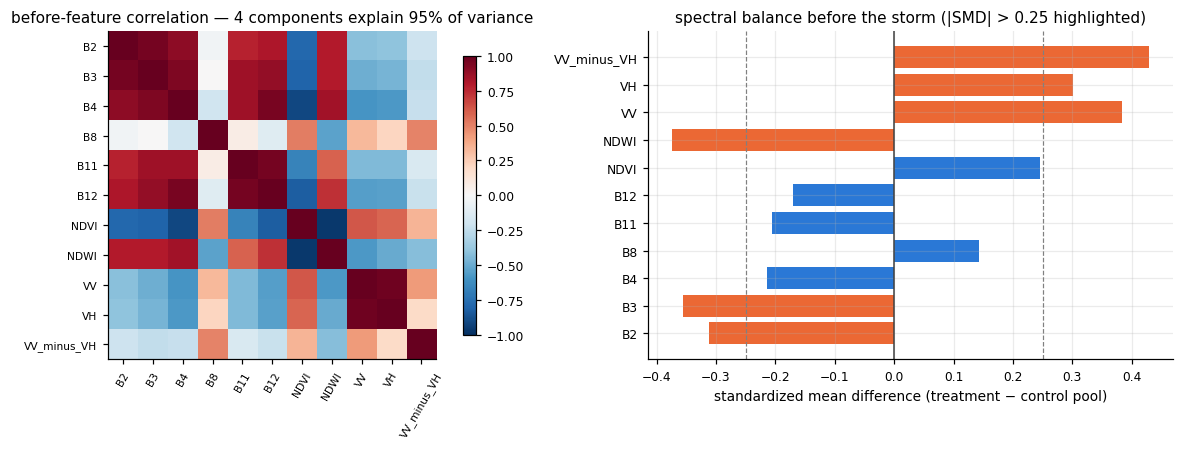

eigenvalues of the 11x11 correlation matrix: [6.98 1.78 1.1  0.65 0.35 0.07 0.05 0.02 0.01 0.   0.  ]
-> effective dimensionality is ~4 (bands are highly collinear: optical bands move together, NDVI/NDWI are derived from them)

standardized mean differences (before period):
band
B2            -0.312
B3            -0.355
B4            -0.215
B8             0.143
B11           -0.207
B12           -0.171
NDVI           0.245
NDWI          -0.374
VV             0.384
VH             0.301
VV_minus_VH    0.429


In [14]:
zs = (before - before.mean()) / before.std()   # standardized before-features

corr = before.corr()
ev = np.linalg.eigvalsh(corr.to_numpy())[::-1]
cum = np.cumsum(ev) / ev.sum()
k95 = int(np.searchsorted(cum, 0.95) + 1)

smd = ((before.loc[tdf["site_id"]].mean() - before.loc[cdf["site_id"]].mean())
       / before.std())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
im = axes[0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(11)); axes[0].set_xticklabels(ALL_BANDS, rotation=60, fontsize=7)
axes[0].set_yticks(range(11)); axes[0].set_yticklabels(ALL_BANDS, fontsize=7)
axes[0].grid(False); axes[0].set_title(
    f"before-feature correlation — {k95} components explain 95% of variance")
plt.colorbar(im, ax=axes[0], shrink=0.85)

axes[1].barh(range(11), smd[ALL_BANDS], color=[C_TREAT if abs(v) > 0.25 else C_CONTROL
                                               for v in smd[ALL_BANDS]])
axes[1].axvline(0, color="0.25", lw=1)
for x in (-0.25, 0.25):
    axes[1].axvline(x, color="0.5", lw=0.8, ls="--")
axes[1].set_yticks(range(11)); axes[1].set_yticklabels(ALL_BANDS, fontsize=8)
axes[1].set_xlabel("standardized mean difference (treatment − control pool)")
axes[1].set_title("spectral balance before the storm (|SMD| > 0.25 highlighted)")
plt.tight_layout(); plt.show()

print("eigenvalues of the 11x11 correlation matrix:", np.round(ev, 2))
print(f"-> effective dimensionality is ~{k95} (bands are highly collinear: "
      "optical bands move together, NDVI/NDWI are derived from them)")
print("\nstandardized mean differences (before period):")
print(smd[ALL_BANDS].round(3).to_string())


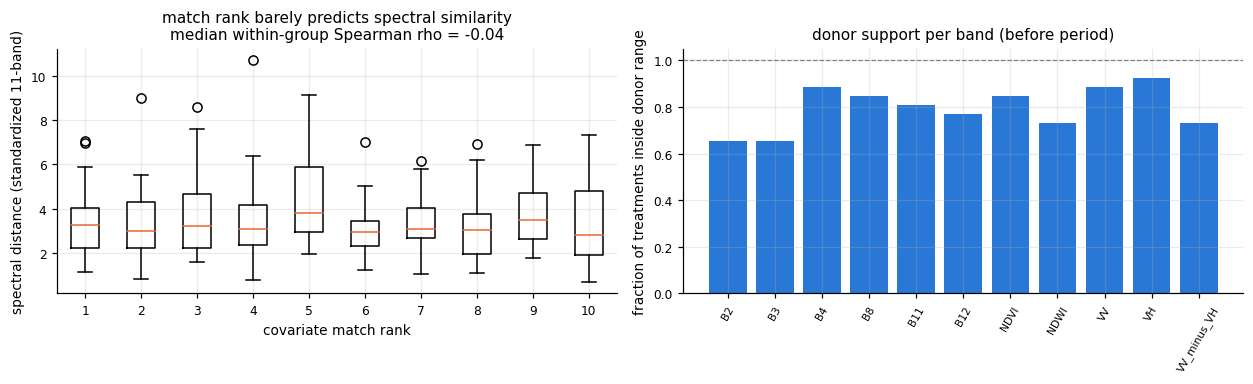

treatments inside their donors' range on ALL 11 bands: 8/26
per-band support (fraction of 26 treatments): min 0.65 (B2), median 0.81

Reading: covariate matching guarantees terrain/land-cover similarity but only
loosely orders donors by spectral similarity, and a treatment's before-state is
usually — not always — spanned by its 10 donors. How a comparison method should
weight these unequal donors is the estimation question taken up in notebook 02.


In [15]:
# (c) does the covariate match rank predict spectral similarity?
from scipy.stats import spearmanr

dist_rows = []
for _, r in match.iterrows():
    d = float(np.linalg.norm(zs.loc[r["treatment_site_id"]]
                             - zs.loc[r["counterfactual_site_id"]]))
    dist_rows.append({"treatment": r["treatment_site_id"],
                      "rank": int(r["control_rank"]), "spectral_dist": d})
dist = pd.DataFrame(dist_rows)
rho_within = dist.groupby("treatment").apply(
    lambda g: spearmanr(g["rank"], g["spectral_dist"]).correlation)

# (d) donor support: is the treatment inside its donors' per-band range?
support_rows = []
for t_id_, grp in match.groupby("treatment_site_id"):
    ctrl_ids_ = grp.sort_values("control_rank")["counterfactual_site_id"].tolist()
    donors = before.loc[ctrl_ids_]
    x = before.loc[t_id_]
    inside = (x >= donors.min()) & (x <= donors.max())
    support_rows.append(inside)
support = pd.DataFrame(support_rows, index=sorted(match["treatment_site_id"].unique()))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
ranks = sorted(dist["rank"].unique())
axes[0].boxplot([dist.loc[dist["rank"] == r, "spectral_dist"] for r in ranks],
                labels=ranks, medianprops=dict(color=C_TREAT))
axes[0].set_xlabel("covariate match rank"); axes[0].set_ylabel("spectral distance (standardized 11-band)")
axes[0].set_title(f"match rank barely predicts spectral similarity\n"
                  f"median within-group Spearman rho = {rho_within.median():.2f}")

frac_inside = support.mean(axis=0).loc[ALL_BANDS]
axes[1].bar(range(11), frac_inside, color=C_CONTROL)
axes[1].set_xticks(range(11)); axes[1].set_xticklabels(ALL_BANDS, rotation=60, fontsize=7)
axes[1].axhline(1.0, color="0.5", lw=0.8, ls="--")
axes[1].set_ylabel("fraction of treatments inside donor range")
axes[1].set_title("donor support per band (before period)")
plt.tight_layout(); plt.show()

n_full = int(support.all(axis=1).sum())
print(f"treatments inside their donors' range on ALL 11 bands: {n_full}/26")
print(f"per-band support (fraction of 26 treatments): min {frac_inside.min():.2f} "
      f"({frac_inside.idxmin()}), median {frac_inside.median():.2f}")
print("\nReading: covariate matching guarantees terrain/land-cover similarity but only")
print("loosely orders donors by spectral similarity, and a treatment's before-state is")
print("usually — not always — spanned by its 10 donors. How a comparison method should")
print("weight these unequal donors is the estimation question taken up in notebook 02.")


## 11. Sub-chip heterogeneity — a landslide is small inside a 1 km window

The USGS inventory gives landslide *points*, and each chip is a 1.01 km square around one.
A landslide scar of a few thousand m² occupies a small percent of the ~1 km² window, so a
chip-mean feature dilutes the scar signal with mostly-unaffected land. The pixel-level
statistics cached in section 8 quantify how severe the dilution is: do treated windows even
show a heavier tail of extreme NDVI drops than control windows?

*Provenance: the landslide point locations are the USGS inventory of
`03_download_usgs.ipynb` (loaded in 06 §7); the 1 km windows around them are 06 §18; the
pixel statistics are ours, from her 07/08 chips.*

/tmp/ipykernel_4142573/245424078.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(im, ax=axes[0], shrink=0.85)


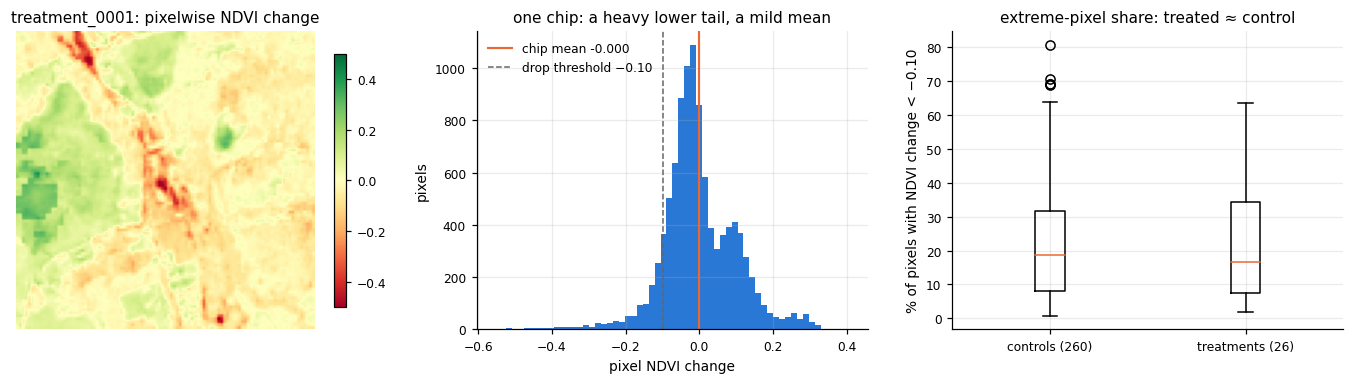

pixels with NDVI drop < -0.10: treatment median 16.6% (max 63.5%), control median 18.6%
pixels with NDVI drop < -0.20: treatment median 2.5%, control median 2.0%
lower-tail change (p05), treatments -0.153 vs controls -0.162

Reading: NO — at the raw pixel level, treated windows are essentially
indistinguishable from control windows, even in the extreme-drop tail:
October senescence produces deep NDVI drops everywhere, and the scar occupies
too small a share of the 1 km window to shift the chip's tail statistics.
This is the strongest form of the dilution point: the treatment signal only
emerges after differencing chip-level features against matched controls
(notebook 02). Landslide footprints, or smaller windows centered on the scar,
would be needed before pixel-level statistics become informative.


In [16]:
s2pix = pix[pix["sensor"] == "sentinel2"].set_index("site_id")
is_t = s2pix.index.str.startswith("treatment")

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))

# example: pixelwise NDVI change at one treatment site
tb = read_chip(chip_path("treatment_0001", "sentinel2", "before"))
ta = read_chip(chip_path("treatment_0001", "sentinel2", "after"))
d = ta[..., 6] - tb[..., 6]
im = axes[0].imshow(d, cmap="RdYlGn", vmin=-0.5, vmax=0.5)
axes[0].axis("off"); axes[0].grid(False)
axes[0].set_title("treatment_0001: pixelwise NDVI change")
plt.colorbar(im, ax=axes[0], shrink=0.85)

axes[1].hist(d[np.isfinite(d)].ravel(), bins=60, color=C_CONTROL)
axes[1].axvline(np.nanmean(d), color=C_TREAT, lw=1.4,
                label=f"chip mean {np.nanmean(d):+.3f}")
axes[1].axvline(-0.10, color="0.4", lw=1, ls="--", label="drop threshold −0.10")
axes[1].set_xlabel("pixel NDVI change"); axes[1].set_ylabel("pixels")
axes[1].set_title("one chip: a heavy lower tail, a mild mean")
axes[1].legend(frameon=False)

data = [100 * s2pix.loc[~is_t, "frac_below_t1"], 100 * s2pix.loc[is_t, "frac_below_t1"]]
axes[2].boxplot(data, labels=["controls (260)", "treatments (26)"],
                medianprops=dict(color=C_TREAT))
axes[2].set_ylabel("% of pixels with NDVI change < −0.10")
axes[2].set_title("extreme-pixel share: treated ≈ control")
plt.tight_layout(); plt.show()

t_frac = s2pix.loc[is_t, "frac_below_t1"]
c_frac = s2pix.loc[~is_t, "frac_below_t1"]
print(f"pixels with NDVI drop < -0.10: treatment median {100*t_frac.median():.1f}% "
      f"(max {100*t_frac.max():.1f}%), control median {100*c_frac.median():.1f}%")
print(f"pixels with NDVI drop < -0.20: treatment median "
      f"{100*s2pix.loc[is_t,'frac_below_t2'].median():.1f}%, control median "
      f"{100*s2pix.loc[~is_t,'frac_below_t2'].median():.1f}%")
print(f"lower-tail change (p05), treatments {s2pix.loc[is_t,'chg_p05'].median():+.3f} "
      f"vs controls {s2pix.loc[~is_t,'chg_p05'].median():+.3f}")
print("\nReading: NO — at the raw pixel level, treated windows are essentially")
print("indistinguishable from control windows, even in the extreme-drop tail:")
print("October senescence produces deep NDVI drops everywhere, and the scar occupies")
print("too small a share of the 1 km window to shift the chip's tail statistics.")
print("This is the strongest form of the dilution point: the treatment signal only")
print("emerges after differencing chip-level features against matched controls")
print("(notebook 02). Landslide footprints, or smaller windows centered on the scar,")
print("would be needed before pixel-level statistics become informative.")


## 12. Dataset summary — what it supports, and what is still missing

| proposal element | status with this dataset |
|---|---|
| Obj. 1 — multimodal pipeline, treated & comparison areas, VA/Appalachia pilot | **done by the collaborator**: reproducible GEE notebooks (`data/scripts/00–09`), matched design, QC files; our pipeline reproduces the `test/` computation to float precision (section 7) |
| Obj. 2 / Module 1 — factual indicators | NDVI, NDWI, SWIR, VV/VH delivered per site & period; EVI and land-surface temperature would need re-export |
| Obj. 3–4 / Module 2 — counterfactual estimators & validation | taken up in `02_did_vs_synthetic_control.ipynb` |
| Obj. 5 / Module 3 — decision-support translation | per-site effect tables are the raw material; county-level economic linkage out of scope for this dataset |

**Dataset facts established here.** All 1,144 documented chips validate (worst valid-pixel
fraction 97.5%; change-mask intersection ≥ ~97% everywhere). The binding measurement limits
are: a single pre-period composite; after-period S1 control chips stacking a median of
1 scene; acquisition metadata (scene counts, S1 orbits) missing for every treatment site —
a fourth skip-existing artifact of the download notebooks; and 5 of 26 donor groups mixing
S1 relative orbits (section 8). The control sites record a large common seasonal shock
(section 9), which any causal contrast must difference out — and with one pre-period, the
parallelism of that seasonal trajectory cannot be tested. The 11 bands are highly collinear
(~4 effective dimensions); covariate matching balances terrain but the match rank carries
essentially no information about spectral similarity, and treatments are not always inside
their donors' spectral range (section 10). At the raw pixel level, treated windows are
indistinguishable from controls even in the extreme-drop tail — seasonal change swamps the
scar at 1 km scale, so the treatment signal exists only *relative to matched controls*
(section 11).

**Gaps that bound what any estimator can claim** (details in tutorial §6): single pre-period
composite (no pre-trend test — a monthly 2023–24 re-export is the highest-value extension),
landslide points without footprints or severity, controls that shared the storm (estimand =
effect of *landslide occurrence*, not of the hurricane), and the NDVI-circularity of the
USGS inventory (S1 is the independent modality).

**Next.** The estimator comparison on this dataset — equal-weight DiD vs estimated-weight
synthetic control, with placebo inference — is `02_did_vs_synthetic_control.ipynb`.